# Analyse lineaire en kwadratische damping — fixed linear, quad only

Deze notebook analyseert de bijgevoegde Excel en maakt plots voor **viskeuze lineaire damping vs kwadratische damping**, en dezelfde plots waarbij **radiation damping bij de lineaire damping is opgeteld**.

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

In [8]:
# =========================
# INPUT / OUTPUT
# =========================
# Pas dit pad eventueel aan als je lokaal werkt.
excel_path = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\calibrated_decay_coefficients_fixed_linear_quad_only.xlsx")

output_dir = excel_path.parent / "damping_analysis_linfixed_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Excel bestand: {excel_path}")
print(f"Outputmap:     {output_dir}")

Excel bestand: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\calibrated_decay_coefficients_fixed_linear_quad_only.xlsx
Outputmap:     C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\damping_analysis_linfixed_outputs


In [9]:
# =========================
# SETTINGS
# =========================
dofs = ["pitch", "roll", "heave"]
detail_sheets = {"pitch": "pitch", "roll": "roll", "heave": "heave"}

# Radiation damping per constructie + DOF
rad_damping_map = {
    ("fixedwith", "pitch"): 142.78,
    ("fixedwith", "roll"): 142.78,
    ("fixedwith", "heave"): 3.05,
    ("fixedwithout", "pitch"): 176.24,
    ("fixedwithout", "roll"): 176.24,
    ("fixedwithout", "heave"): 4.00,
    ("spring", "pitch"): 88.35,
    ("spring", "roll"): 82.50,
    ("spring", "heave"): 2.23,
}

TITLE_SIZE = 14
LABEL_SIZE = 12
TICK_SIZE = 10

color_map = {
    "fixedwith": "green",
    "fixedwithout": "tab:blue",
    "spring": "orange",
}

marker_map = {
    "fixedwith": "o",
    "fixedwithout": "s",
    "spring": "^",
}

In [10]:
# =========================
# DATA INLADEN + RADIATION DAMPING TOEVOEGEN
# =========================
all_details = []

for dof in dofs:
    df = pd.read_excel(excel_path, sheet_name=detail_sheets[dof])
    df.columns = [str(c).strip() for c in df.columns]

    df["construction"] = df["construction"].astype(str).str.strip().str.lower()
    df["dof"] = df["dof"].astype(str).str.strip().str.lower()

    # Robuuste kolomnamen, zodat de code ook werkt als je notebook input_linear/input_quadratic gebruikt
    if "input_linear_damping" not in df.columns:
        if "linear_damping" in df.columns:
            df["input_linear_damping"] = df["linear_damping"]
        elif "linear_damping_fixed" in df.columns:
            df["input_linear_damping"] = df["linear_damping_fixed"]
        else:
            raise KeyError("Geen kolom gevonden voor lineaire damping")

    if "input_quadratic_damping" not in df.columns:
        if "quadratic_damping" in df.columns:
            df["input_quadratic_damping"] = df["quadratic_damping"]
        else:
            raise KeyError("Geen kolom gevonden voor kwadratische damping")

    df["radiation_damping"] = df.apply(
        lambda row: rad_damping_map[(row["construction"], row["dof"])],
        axis=1,
    )
    df["total_linear_damping"] = df["input_linear_damping"] + df["radiation_damping"]

    all_details.append(df)

all_details = pd.concat(all_details, ignore_index=True)
constructions = [c for c in ["fixedwith", "fixedwithout", "spring"] if c in all_details["construction"].unique()]

print("Aantal rijen:", len(all_details))
print("Constructies:", constructions)
print("DOFs:", sorted(all_details["dof"].unique()))
display(all_details.head())

Aantal rijen: 33
Constructies: ['fixedwith', 'fixedwithout', 'spring']
DOFs: ['heave', 'pitch', 'roll']


,construction,dof,exp_path,file_name,initial_amplitude_A1,extremum_type,sim_init_time,sim_init_amplitude,linear_damping_fixed,linear_damping,quadratic_damping,nmrse_total,nrmse_peaks,nrmse_troughs,input_linear_damping,input_quadratic_damping,radiation_damping,total_linear_damping
0,fixedwith,pitch,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_003_001_01_Decay1.h5m,9.141772,peak,0,6.935063,277.777778,277.777778,1350.000000,0.125606,0.125109,0.126103,277.777778,1350.000000,142.78,420.557778
1,fixedwith,pitch,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_003_002_01_Decay1.h5m,9.001547,peak,0,6.874804,277.777778,277.777778,636.666667,0.053179,0.050754,0.055605,277.777778,636.666667,142.78,420.557778
2,fixedwith,pitch,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_003_003_01_Decay1.h5m,10.024397,peak,0,7.563487,277.777778,277.777778,0.000000,0.110084,0.111060,0.109108,277.777778,0.000000,142.78,420.557778
3,fixedwithout,pitch,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_004_001_01_Decay1.h5m,-7.020535,trough,0,-5.782496,164.166667,164.166667,1050.000000,0.087219,0.087205,0.087232,164.166667,1050.000000,176.24,340.406667
4,fixedwithout,pitch,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_004_002_01_Decay1.h5m,11.111569,peak,0,8.185949,164.166667,164.166667,1350.000000,0.085199,0.080620,0.089778,164.166667,1350.000000,176.24,340.406667


In [11]:
# =========================
# SUMMARY PER CONSTRUCTIE + DOF
# =========================
summary = (
    all_details
    .groupby(["construction", "dof"], as_index=False)
    .agg(
        n_experiments=("file_name", "count"),
        mean_viscous_linear_damping=("input_linear_damping", "mean"),
        mean_radiation_damping=("radiation_damping", "mean"),
        mean_total_linear_damping=("total_linear_damping", "mean"),
        mean_quadratic_damping=("input_quadratic_damping", "mean"),
        std_quadratic_damping=("input_quadratic_damping", "std"),
        mean_nrmse_total=("nmrse_total", "mean"),
    )
)

summary_path = output_dir / "summary_construction_dof_linfixed.xlsx"
summary.to_excel(summary_path, index=False)

display(summary)
print(f"Samenvatting opgeslagen als: {summary_path}")

,construction,dof,n_experiments,mean_viscous_linear_damping,mean_radiation_damping,mean_total_linear_damping,mean_quadratic_damping,std_quadratic_damping,mean_nrmse_total
0,fixedwith,heave,4,1.833333,3.05,4.883333,4.000000,1.172604,0.242626
1,fixedwith,pitch,3,277.777778,142.78,420.557778,662.222222,675.362728,0.096290
2,fixedwith,roll,3,254.444444,142.78,397.224444,717.777778,679.054353,0.137156
3,fixedwithout,heave,4,0.687500,4.00,4.687500,1.562500,0.746520,0.147994
4,fixedwithout,pitch,4,164.166667,176.24,340.406667,1220.000000,137.113092,0.087062
5,fixedwithout,roll,4,134.166667,176.24,310.406667,590.000000,695.269732,0.085145
6,spring,heave,4,3.000000,2.23,5.230000,2.625000,1.436141,0.173727
7,spring,pitch,3,320.000000,88.35,408.350000,114.444444,198.223592,0.044007
8,spring,roll,4,293.333333,82.50,375.833333,296.666667,349.253171,0.064423


Samenvatting opgeslagen als: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\damping_analysis_linfixed_outputs\summary_construction_dof_linfixed.xlsx


In [12]:
# =========================
# DOF GLOBAL SUMMARY
# =========================
dof_global = (
    all_details
    .groupby("dof", as_index=False)
    .agg(
        n_experiments=("file_name", "count"),
        dof_global_lin_viscous_mean=("input_linear_damping", "mean"),
        dof_global_radiation_mean=("radiation_damping", "mean"),
        dof_global_lin_total_mean=("total_linear_damping", "mean"),
        dof_global_quad_mean=("input_quadratic_damping", "mean"),
        dof_global_quad_std=("input_quadratic_damping", "std"),
        mean_nrmse_total=("nmrse_total", "mean"),
    )
)

dof_global_path = output_dir / "summary_dof_global_linfixed.xlsx"
dof_global.to_excel(dof_global_path, index=False)

display(dof_global)
print(f"DOF-global samenvatting opgeslagen als: {dof_global_path}")

,dof,n_experiments,dof_global_lin_viscous_mean,dof_global_radiation_mean,dof_global_lin_total_mean,dof_global_quad_mean,dof_global_quad_std,mean_nrmse_total
0,heave,12,1.840278,3.093333,4.933611,2.729167,1.475013,0.188116
1,pitch,10,245.000000,139.835000,384.835000,721.000000,592.294242,0.076914
2,roll,11,224.848485,133.027273,357.875758,518.181818,554.507517,0.091795


DOF-global samenvatting opgeslagen als: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\damping_analysis_linfixed_outputs\summary_dof_global_linfixed.xlsx


In [20]:
# =========================
# PLOTFUNCTIE
# =========================
def get_units_and_limits(dof):
    dof = dof.lower()
    if dof == "heave":
        return 0, 0, "[kN/(m/s)]", "[kN/(m/s)^2]"
    if dof in ["pitch", "roll"]:
        return 0, -30, "[(kNm)/(rad/s)]", "[(kNm)/(rad/s)^2]"
    return None, None, "", ""


def plot_lin_vs_quad(include_radiation=False, show_construction_mean=True, show_dof_global_mean=True, output_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False, sharey=False)

    for ax, dof in zip(axes, dofs):
        x_left, y_bottom, lin_unit, quad_unit = get_units_and_limits(dof)
        details_dof = all_details[all_details["dof"].str.lower() == dof.lower()].copy()
        summary_dof = summary[summary["dof"].str.lower() == dof.lower()].copy()
        dof_global_dof = dof_global[dof_global["dof"].str.lower() == dof.lower()].copy()

        for construction in constructions:
            color = color_map.get(construction)
            marker = marker_map.get(construction, "o")
            sub_details = details_dof[details_dof["construction"] == construction].copy()
            if sub_details.empty:
                continue

            if include_radiation:
                x_values = sub_details["total_linear_damping"]
                xlabel = f"Total linear damping {lin_unit}"
            else:
                x_values = sub_details["input_linear_damping"]
                xlabel = f"Viscous linear damping {lin_unit}"

            ax.scatter(
                x_values,
                sub_details["input_quadratic_damping"],
                marker=marker,
                s=70,
                color=color,
                alpha=0.75,
                label=f"{construction} - individueel",
            )

            # if show_construction_mean:
            #     sub_summary = summary_dof[summary_dof["construction"] == construction]
            #     if not sub_summary.empty:
            #         row = sub_summary.iloc[0]
            #         x_mean = row["mean_total_linear_damping"] if include_radiation else row["mean_viscous_linear_damping"]
            #         ax.scatter(
            #             x_mean,
            #             row["mean_quadratic_damping"],
            #             marker="X",
            #             s=170,
            #             color=color,
            #             edgecolor="black",
            #             linewidth=0.8,
            #             label=f"{construction} - mean",
            #         )

        # if show_dof_global_mean and not dof_global_dof.empty:
        #     row_global = dof_global_dof.iloc[0]
        #     x_global = row_global["dof_global_lin_total_mean"] if include_radiation else row_global["dof_global_lin_viscous_mean"]
        #     ax.scatter(
        #         x_global,
        #         row_global["dof_global_quad_mean"],
        #         marker="*",
        #         s=260,
        #         color="black",
        #         edgecolor="white",
        #         linewidth=1.0,
        #         label="DOF-global mean",
        #     )

        ax.set_title(f"{dof.capitalize()}", fontsize=TITLE_SIZE)
        ax.set_xlabel(xlabel, fontsize=LABEL_SIZE)
        ax.set_ylabel(f"Quadratic damping {quad_unit}", fontsize=LABEL_SIZE)
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(left=x_left)
        ax.set_ylim(bottom=y_bottom)

    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    unique = dict(zip(labels, handles))
    fig.legend(
        unique.values(),
        unique.keys(),
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, -0.13),
    )

    title = "Linear vs Quadratic Damping per DOF (incl. radiation damping)" if include_radiation else "Linear vs Quadratic Damping per DOF (viscous damping only)"
    fig.suptitle(title, fontsize=16)
    fig.tight_layout(rect=[0, 0.13, 1, 0.95])

    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Plot opgeslagen als: {output_path}")

    plt.show()

Plot opgeslagen als: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\damping_analysis_linfixed_outputs\lin_vs_quad_viscous_only.png


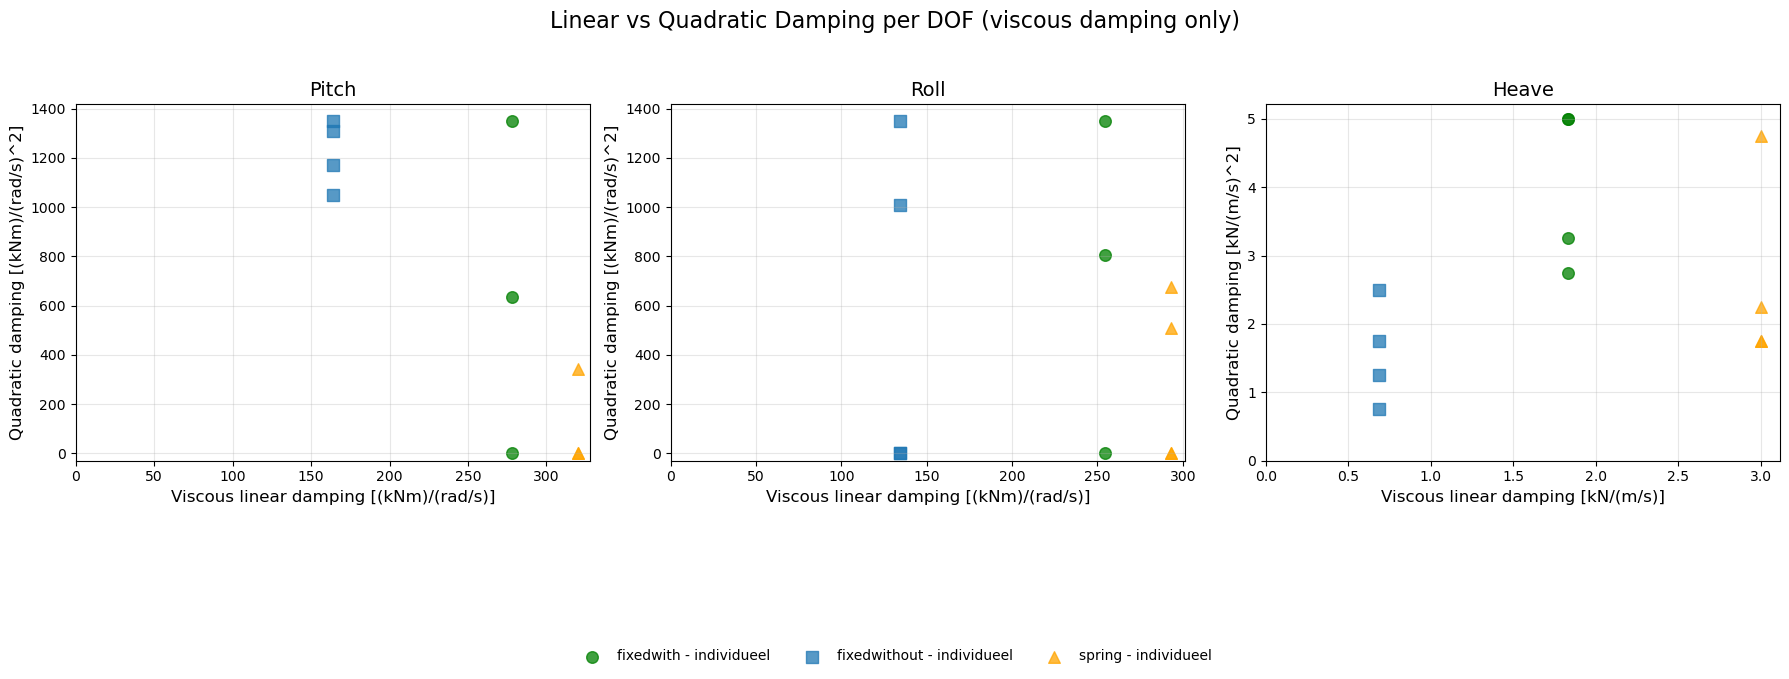

In [21]:
# =========================
# PLOT 1: VISCOUS ONLY
# =========================
plot_lin_vs_quad(
    include_radiation=False,
    show_construction_mean=True,
    show_dof_global_mean=True,
    output_path=output_dir / "lin_vs_quad_viscous_only.png",
)

Plot opgeslagen als: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\damping_analysis_linfixed_outputs\lin_vs_quad_incl_radiation.png


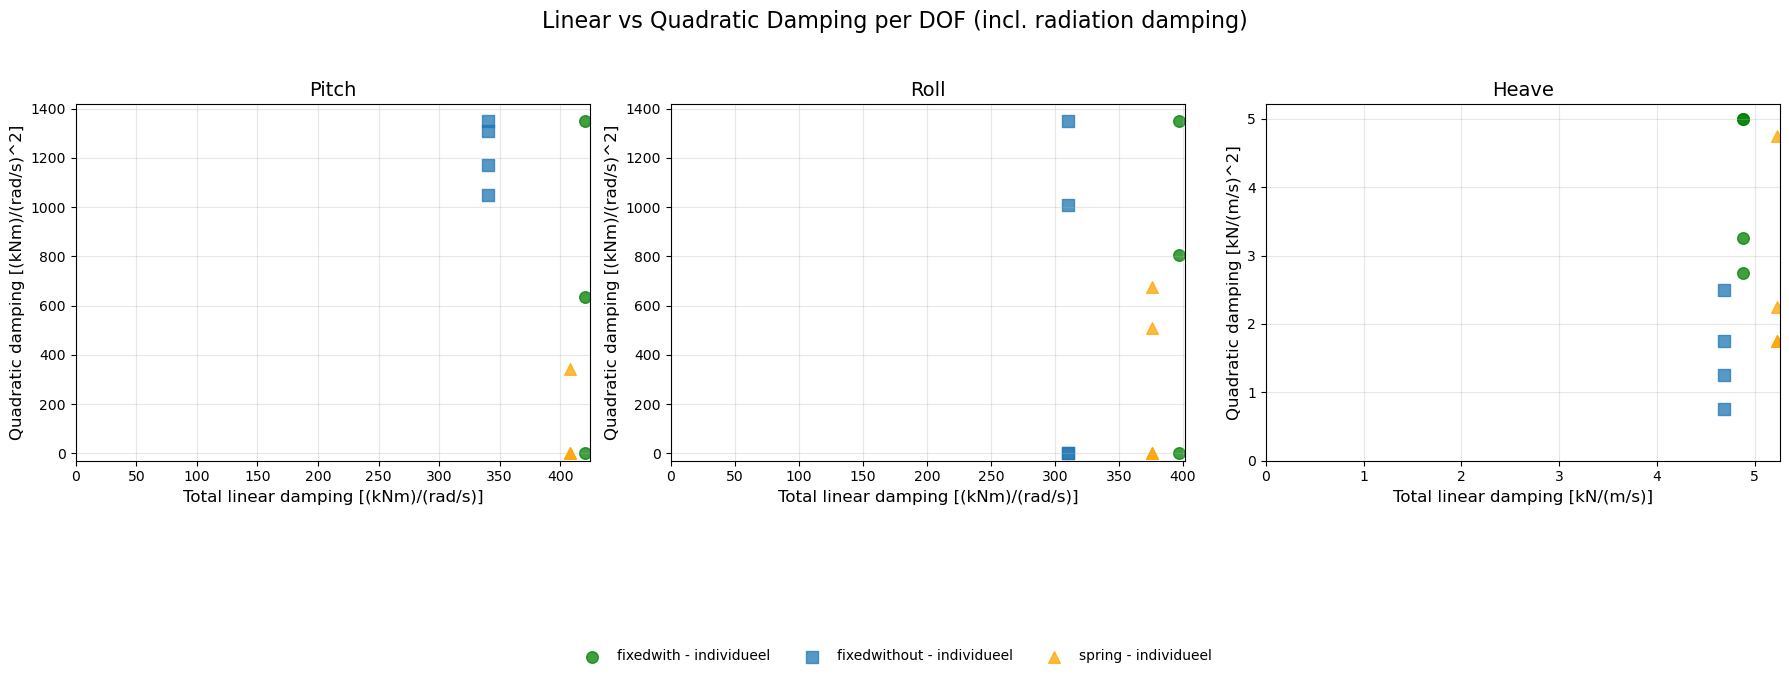

In [22]:
# =========================
# PLOT 2: INCL. RADIATION DAMPING
# =========================
plot_lin_vs_quad(
    include_radiation=True,
    show_construction_mean=True,
    show_dof_global_mean=True,
    output_path=output_dir / "lin_vs_quad_incl_radiation.png",
)

Plot opgeslagen als: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\damping_analysis_linfixed_outputs\lin_vs_quad_viscous_only_individual_only.png


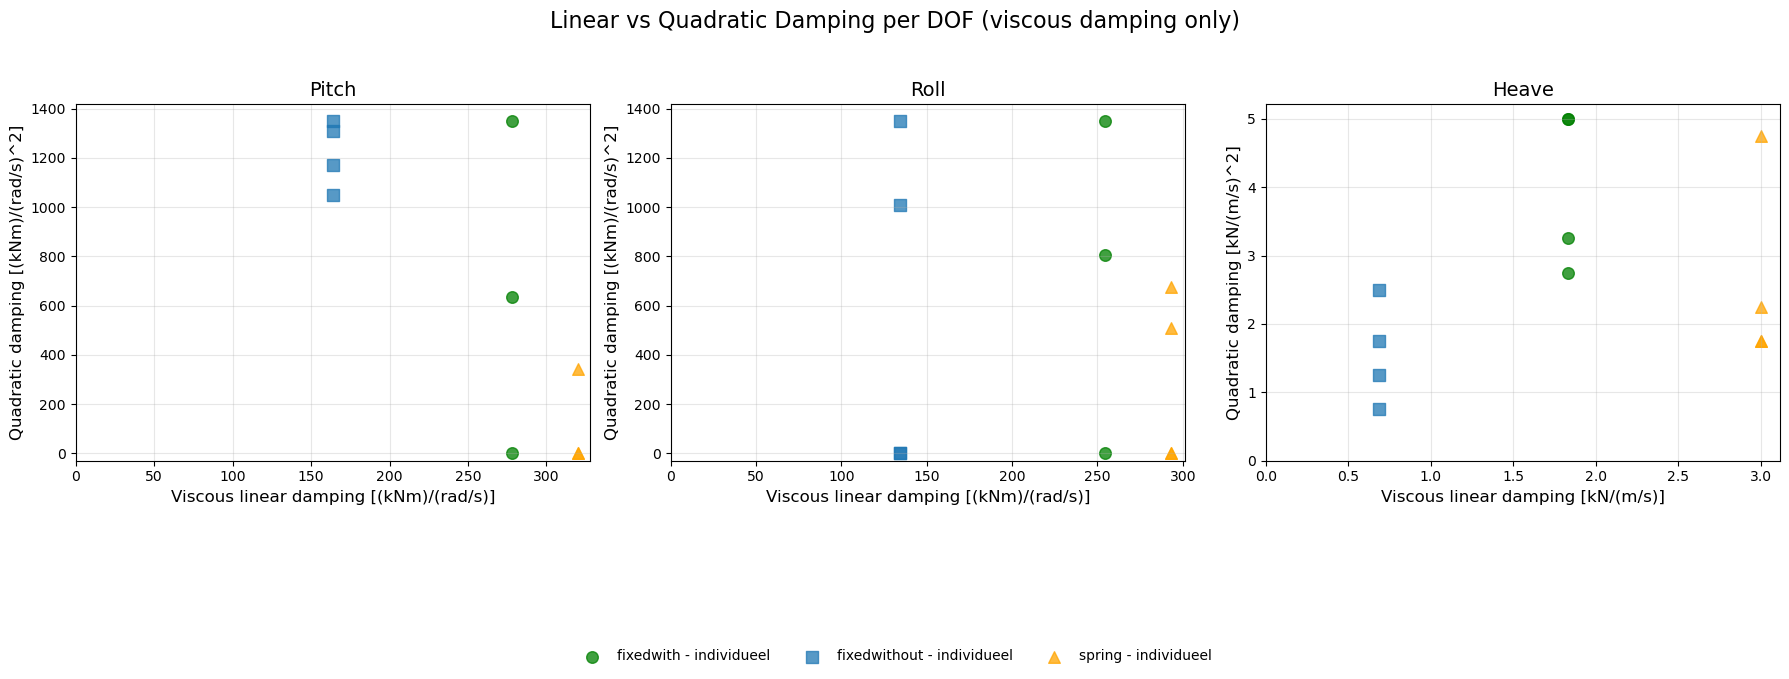

Plot opgeslagen als: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\damping_analysis_linfixed_outputs\lin_vs_quad_incl_radiation_individual_only.png


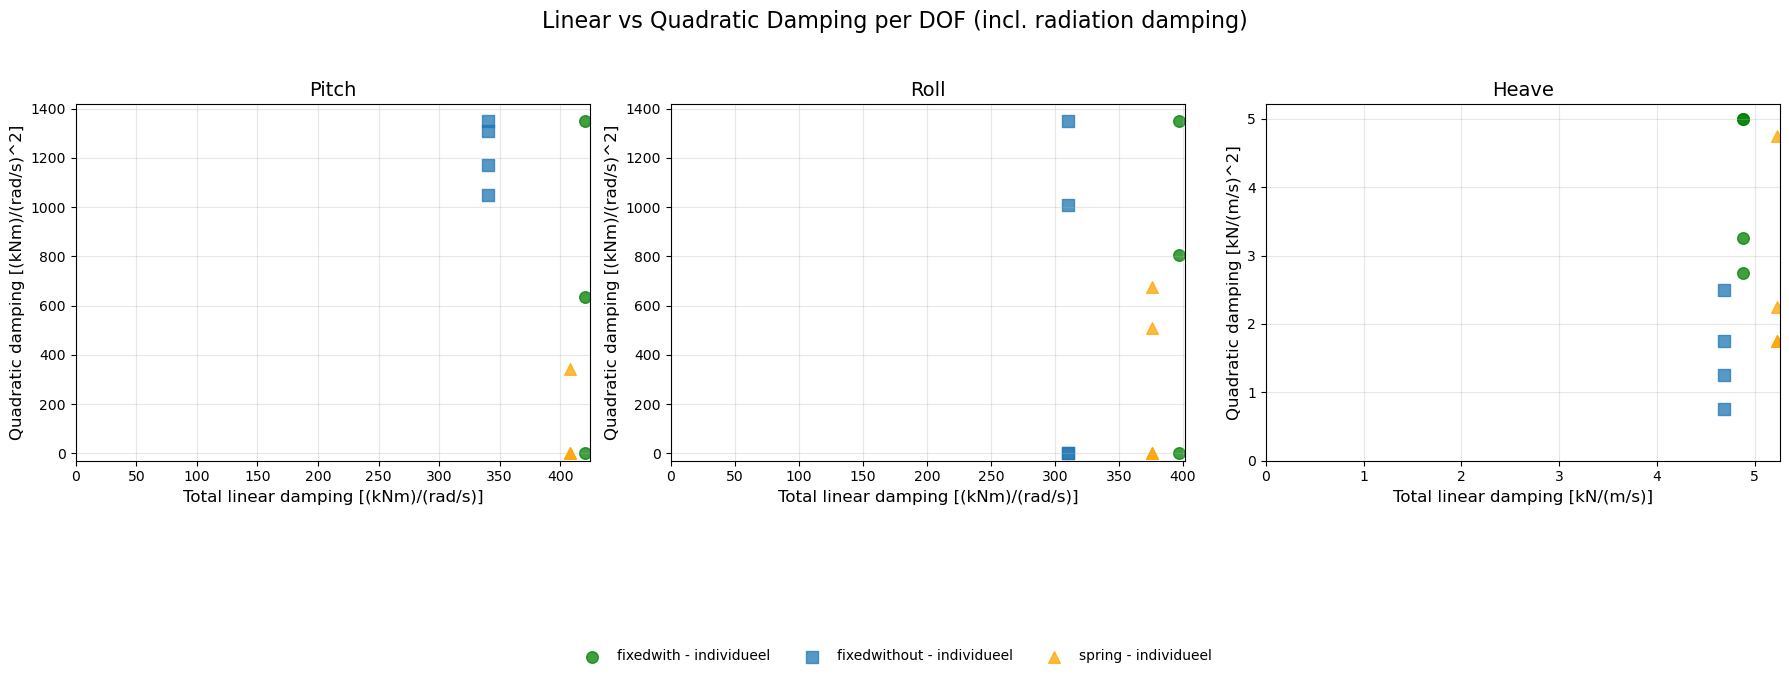

In [16]:
# =========================
# EXTRA: ALLEEN INDIVIDUELE PUNTEN, ZOALS IN JE VOORBEELD
# =========================
plot_lin_vs_quad(
    include_radiation=False,
    show_construction_mean=False,
    show_dof_global_mean=False,
    output_path=output_dir / "lin_vs_quad_viscous_only_individual_only.png",
)

plot_lin_vs_quad(
    include_radiation=True,
    show_construction_mean=False,
    show_dof_global_mean=False,
    output_path=output_dir / "lin_vs_quad_incl_radiation_individual_only.png",
)

In [17]:
# =========================
# EXPORT: ANALYSE EXCEL MET RADIATION DAMPING ERBIJ
# =========================
analysis_excel_path = output_dir / "damping_analysis_linfixed_with_radiation.xlsx"

with pd.ExcelWriter(analysis_excel_path, engine="openpyxl") as writer:
    all_details.to_excel(writer, sheet_name="all_details", index=False)
    summary.to_excel(writer, sheet_name="summary_construction_dof", index=False)
    dof_global.to_excel(writer, sheet_name="dof_global_summary", index=False)

print(f"Analyse Excel opgeslagen als: {analysis_excel_path}")

Analyse Excel opgeslagen als: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs\damping_analysis_linfixed_outputs\damping_analysis_linfixed_with_radiation.xlsx


## Output

Na het draaien van de notebook staan in de outputmap:

- `lin_vs_quad_viscous_only.png`
- `lin_vs_quad_incl_radiation.png`
- `lin_vs_quad_viscous_only_individual_only.png`
- `lin_vs_quad_incl_radiation_individual_only.png`
- `damping_analysis_linfixed_with_radiation.xlsx`
- `summary_construction_dof_linfixed.xlsx`
- `summary_dof_global_linfixed.xlsx`